<a href="https://colab.research.google.com/github/KrzysztofDrobnik/lecture1/blob/regresja/Drzewa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd

from sklearn import datasets
data = datasets.load_iris()

X = data.data
y = data.target


In [78]:
df = pd.DataFrame(data = X, columns=data.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [79]:
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


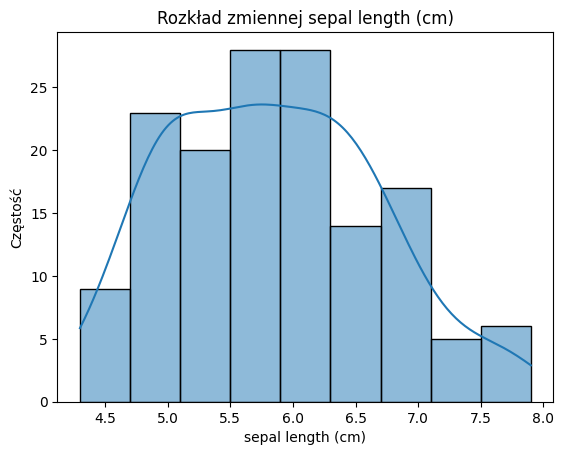

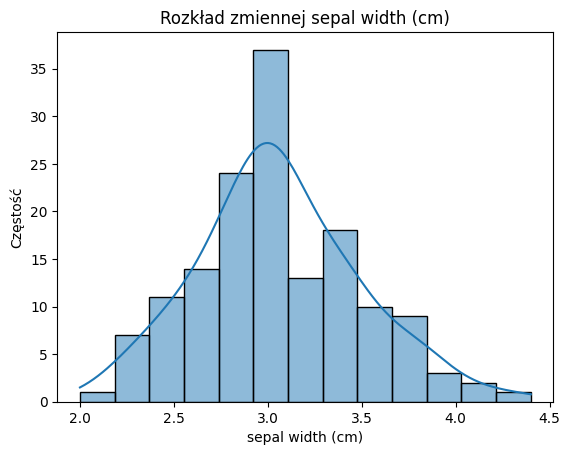

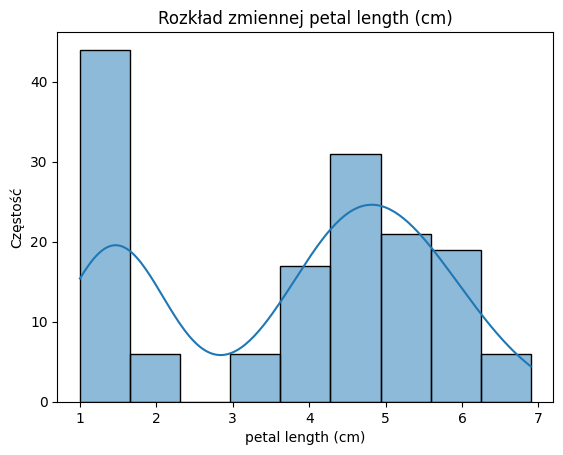

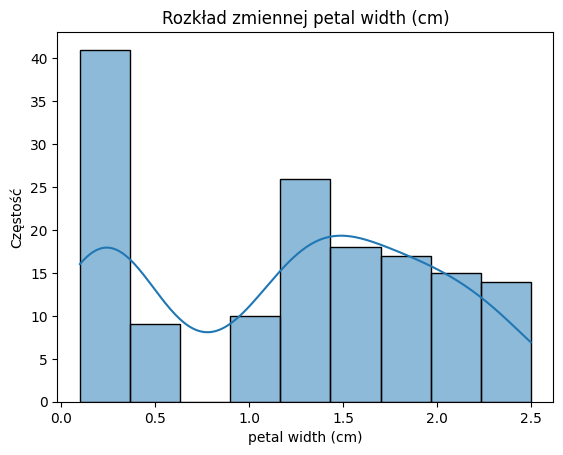

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt


for col in df.columns[:-1]:
    sns.histplot(df[col], kde=True)
    plt.title(f'Rozkład zmiennej {col}')
    plt.xlabel(col)
    plt.ylabel('Częstość')
    plt.show()

In [81]:
def licz_entropie(size1, size2, size3):
  wielkość_próbki = size1 + size2 + size3
  p1 = size1 / wielkość_próbki
  p2 = size2 / wielkość_próbki
  p3 = size3 / wielkość_próbki
  entropy = -p1 * np.log2(p1) - p2 * np.log2(p2) - p3 * np.log2(p3)
  return entropy

def licz_entropie_dla_2_wartosci(size1, size2):
  wielkość_próbki = size1 + size2
  p1 = size1 / wielkość_próbki
  p2 = size2 / wielkość_próbki

  entropy = -p1 * np.log2(p1) - p2 * np.log2(p2)
  return entropy

In [82]:
entropia_całego_zbioru = licz_entropie(50, 50, 50)
print(f"Entropia całego zbioru: {entropia_całego_zbioru}")

Entropia całego zbioru: 1.584962500721156


In [83]:
grupa_1 = df[df['petal width (cm)'] <= 1.5]
grupa_2 = df[df['petal width (cm)'] > 1.5]

In [84]:
grupa_1['target'].value_counts()

,count
target,
0,50
1,45
2,3


In [85]:
grupa_2['target'].value_counts()

,count
target,
2,47
1,5


In [86]:
entropia_grupa1 = licz_entropie(50, 45, 3)
entropia_grupa2 = licz_entropie_dla_2_wartosci(47, 5)
print(f"Entropia grupy 1: {entropia_grupa1}")
print(f"Entropia grupy 2: {entropia_grupa2}")



Entropia grupy 1: 1.1649028407913813
Entropia grupy 2: 0.4566836315394428


In [87]:
entropia_wazona = (98/150) *entropia_grupa1 + (52/150)*entropia_grupa2
print(f"Entropia ważona: {entropia_wazona}")

Entropia ważona: 0.9193868482507093


In [88]:
zysk_informacyjny = entropia_całego_zbioru - entropia_wazona
print(f"Zysk informacyjny: {zysk_informacyjny}")

Zysk informacyjny: 0.6655756524704468


In [89]:
grupa_1_2 = df[df['petal width (cm)'] <= 0.38]
grupa_2_2 = df[df['petal width (cm)'] > 0.38]

In [90]:
grupa_1_2['target'].value_counts()

,count
target,
0,41


In [91]:
grupa_2_2['target'].value_counts()

,count
target,
1,50
2,50
0,9


In [92]:
entropia_grupa_1_2 = (-1)*(41/41)*np.log2(41/41)
entropia_grupa_2_2 = licz_entropie(50, 50, 9)

print(f"Entropia grupy 1_2: {entropia_grupa_1_2}")
print(f"Entropia grupy 2_2: {entropia_grupa_2_2}")

Entropia grupy 1_2: -0.0
Entropia grupy 2_2: 1.3285976826626762


In [93]:
entropa_wazona_2 = (41/150) *entropia_grupa_1_2 + (109/150)*entropia_grupa_2_2
print(f"Entropia ważona: {entropa_wazona_2}")

Entropia ważona: 0.9654476494015447


In [94]:
zysk_informacyjny_2 = entropia_całego_zbioru - entropa_wazona_2
print(f"Zysk informacyjny: {zysk_informacyjny_2}")

Zysk informacyjny: 0.6195148513196114


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42,criterion='entropy')
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

random_forest = RandomForestClassifier(n_estimators=15, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy:", accuracy_dt)
print("Random Forest Accuracy:", accuracy_rf)

Decision Tree Accuracy: 0.9777777777777777
Random Forest Accuracy: 1.0
